In [2]:
%pip install onnxruntime numpy pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import io
import numpy as np
from PIL import Image
import onnxruntime as ort

In [5]:
sess = ort.InferenceSession('best.onnx')
sess

In [6]:
SIZE=sess.get_inputs()[0].shape[2:]
SIZE

[224, 224]

In [8]:
with open("test.jpg", "rb") as f:
    img=f.read()

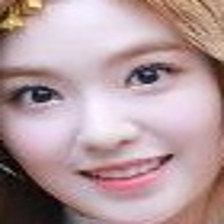

In [9]:
img = Image.open(io.BytesIO(img)).convert('RGB').resize(SIZE)
img

In [10]:
x=np.array(img,np.float32)/255.0
x=np.transpose(x,(2,0,1))
x=np.expand_dims(x,axis=0)
x

array([[[[0.7254902 , 0.7137255 , 0.6745098 , ..., 0.7882353 ,
          0.80784315, 0.8156863 ],
         [0.7019608 , 0.6901961 , 0.65882355, ..., 0.78039217,
          0.8       , 0.80784315],
         [0.6509804 , 0.6431373 , 0.627451  , ..., 0.7607843 ,
          0.77254903, 0.78039217],
         ...,
         [0.14509805, 0.14509805, 0.14509805, ..., 0.57254905,
          0.57254905, 0.5686275 ],
         [0.14509805, 0.14509805, 0.14509805, ..., 0.5803922 ,
          0.5803922 , 0.5803922 ],
         [0.14509805, 0.14509805, 0.14509805, ..., 0.5803922 ,
          0.5803922 , 0.5803922 ]],

        [[0.5568628 , 0.54509807, 0.50980395, ..., 0.6509804 ,
          0.67058825, 0.6784314 ],
         [0.53333336, 0.52156866, 0.49411765, ..., 0.6431373 ,
          0.6627451 , 0.67058825],
         [0.48235294, 0.4745098 , 0.45882353, ..., 0.62352943,
          0.63529414, 0.6431373 ],
         ...,
         [0.10980392, 0.10980392, 0.10980392, ..., 0.46666667,
          0.46666667, 0.4

In [11]:
with open('classes.txt') as f:
    classes=f.readlines()
input_name = sess.get_inputs()[0].name
outputs = sess.run(None, {input_name: x})
pred = classes[outputs[0].argmax()]
pred

'여름 쿨톤'